# Classical Machine Learning [CML]: Assignment

## 0. Assignment Metadata

### 0.0 Word Count

In [31]:
import json

def count_chars(filename):
    with open(filename) as f:
        nb = json.load(f)
    
    counts = {'code': 0, 'markdown': 0, 'raw': 0, 'other': 0}

    for cell in nb['cells']:
        cell_type = cell['cell_type']
        chars = sum(len(line) for line in cell['source'])
        if cell_type in counts:
            counts[cell_type] += chars
        else:
            counts['other'] += chars
    
    total = sum(counts.values())

    for cell_type in ['code', 'markdown', 'raw', 'other']:
        print(f'{cell_type}, {counts[cell_type]}')

    print(f'total, {total}')

    if total > 75000:
        print('Too many characters in assignment submission (> 75,000)')
    else:
        print('Number of characters ok (< 75,000)')
    
count_chars('cml-assignment.ipynb')

code, 1606
markdown, 5257
raw, 0
other, 0
total, 6863
Number of characters ok (< 75,000)


### 0.1 Table of Contents

- [1. `dataset_1.csv`](#1-dataset_1csv)
    - [1.1 Introduction](#11-introduction)
    - [1.2 Load the Required Libraries](#12-load-the-required-libraries)
    - [1.3 Load the Data into a Dataframe](#13-load-the-data-into-a-dataframe)
    - [1.4 Clean the Data](#14-clean-the-data)
    - [1.5 Select Clustering Algorithms](#15-select-clustering-algorithms)
    - 1.6 DBSCAN
    - 1.7 HDBSCAN
    - 1.8 Optics
- [2. `dataset_2.csv`](#2-dataset_2csv)
- [3. `dataset_3.csv`](#3-dataset_3csv)
- [4. `dataset_4.csv`](#4-dataset_4csv)
- [A. Appendix](#a-appendix)
    - [A.1 References](#a1-references)

## 1. `dataset_1.csv`

### 1.1 Introduction

The following section will explore a number of different techniques to determine the optimum number of clusters for the dataset under observation, which is provided in `dataset_1.csv`.

### 1.2 Load the Required Libraries

Before we can perform any analysis on the dataset we first need to import the relevant **Python** libraries. 

In [152]:
import pandas as pd
from pandas.plotting import scatter_matrix
from sklearn import preprocessing, metrics
from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans, SpectralClustering, DBSCAN, HDBSCAN, OPTICS
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
from mpl_toolkits.mplot3d import Axes3D
import plotly.express as px
import optuna

/Users/alexrandall/Documents/Oxford/Coursework/CML/Assignment/cml-assignment/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


- We import `pandas`, a python library which allows us to work with dataframes.
    - `pandas` also contains the `scatter_matrix` module, which we will use to derive any relationship between the different features present in the dataset.
- `sklearn` provides many machine learning algorithms and utility functions, including `preprocessing` for data standardisation and `KMeans` which uses an iterative process to cluster data.
- `numpy` is a popular library that is ideal for working with multi-dimensional arrays.
- Many plotting libraries, including:
    - `matplotlib.pyplot` for plotting graphs.
    - `seaborn` for plotting `pairplots`.
    - `missingno`for missing data identification.
    - `mpl_toolkits.mplot3d` and `plotly.express` for three-dimensional data visualisation.


### 1.3 Load the Data into a Dataframe

First, we read the dataset into `dataset_1` using the `read_csv()` method provided by `pandas`.

In [125]:
dataset_1 = pd.read_csv('CML_2026-04-27#3-dataset1.csv')

Then, we display the dataset:

In [126]:
dataset_1

,x,y
0,0.46544,0.94983
1,0.68888,-0.44487
2,1.83610,0.12347
3,0.75223,0.70726
4,-0.32186,0.86340
...,...,...
1095,-3.26696,-1.06445
1096,-3.31567,1.45050
1097,-2.46885,-2.36481
1098,-2.32953,2.66412


### 1.4 Clean the Data

Before we can feed our dataset into any machine learning or data visualisation algorithm we must first ensure that all the data features are in the correct **format** and **standardised** appropriately. In addition, any **missing values** must be **removed** or **imputed**, depending on its effect on the overall model.

#### 1.4.1 Missing Data Visualisation

Lets first utilise `pandas`'s `isnull()` method to determine whether any of the features contain missing values:

In [127]:
print(f'Missing null counts = \n{dataset_1.isnull().sum()}')

Missing null counts = 
x    0
y    0
dtype: int64


We can also use the `matrix` provided by `missingno` to get a more visual idea of any potential missing datapoints:

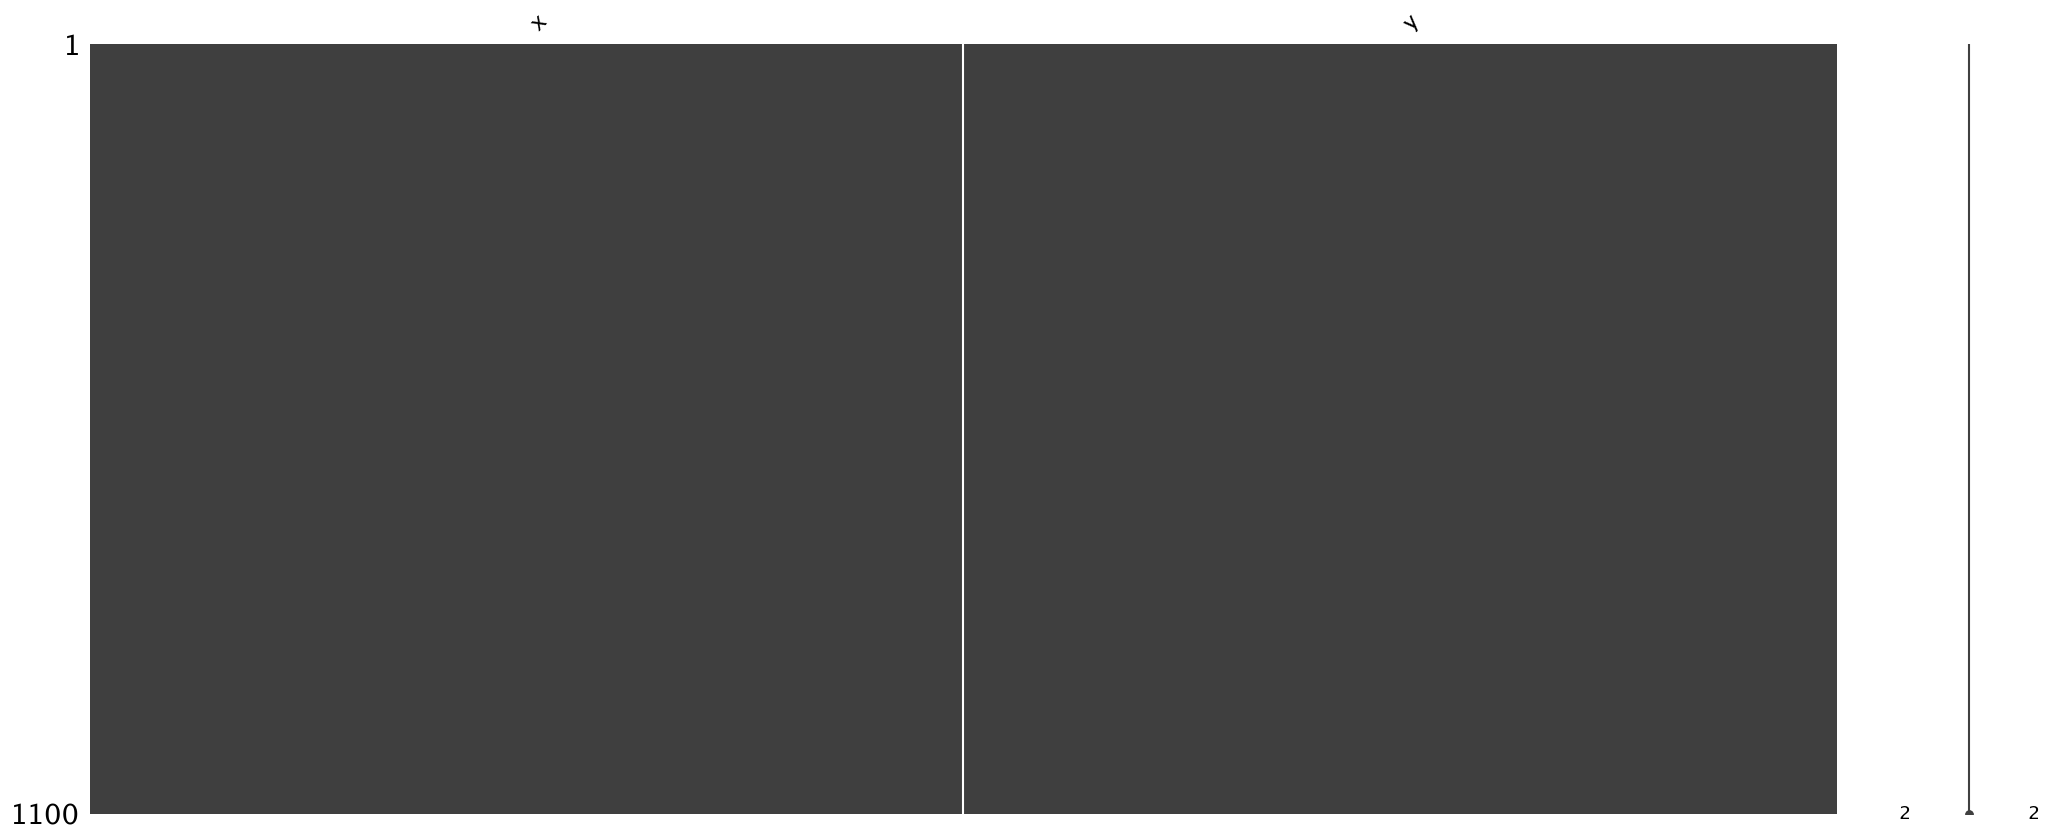

In [128]:
%matplotlib inline

msno.matrix(dataset_1)
plt.show()

*<center>Figure 1: Missing Data Visualisation</center>*

As a result, we can be reasonably confident that none of the features, `x` or `y`, contain any `null` values.

#### 1.4.2 Format Decimal Places

Another technique to clean the data would be to limit the number of decimal places in each of the features. However, we do not want to lose useful information about the underlying data in the process.

If we take another look at the data:

In [129]:
dataset_1

,x,y
0,0.46544,0.94983
1,0.68888,-0.44487
2,1.83610,0.12347
3,0.75223,0.70726
4,-0.32186,0.86340
...,...,...
1095,-3.26696,-1.06445
1096,-3.31567,1.45050
1097,-2.46885,-2.36481
1098,-2.32953,2.66412


The features `x` and `y` resemble coordinates, and the more decimal places there are in a set of coordinates, the more precise the coordinates will be.[<sup>1</sup>](#a1-references)

However, if we set the number of decimal places to `5`, we should retain an accuracy to `1.11 meters` in the underlying data whilst also reducing the computational power and execution time of the underlying model.

In [130]:
pd.set_option('display.float_format', '{:.5f}'.format)

In [131]:
dataset_1

,x,y
0,0.46544,0.94983
1,0.68888,-0.44487
2,1.83610,0.12347
3,0.75223,0.70726
4,-0.32186,0.86340
...,...,...
1095,-3.26696,-1.06445
1096,-3.31567,1.45050
1097,-2.46885,-2.36481
1098,-2.32953,2.66412


#### 1.4.3 Standardise the Data

Before we feed the dataset into a model to be trained and tested, **standardisation** is an often useful technique to improve the efficiency of machine learning algorithms by scaling them to a width that is easier to digest by the underlying model but also retains the structure of the model without removing useful information.

Let's pass our dataframe into the `scale()` method provided by `sklearn`'s `preprocessing` module:

In [132]:
standardised_dataset_1 = preprocessing.scale(dataset_1)
standardised_dataset_1_df = pd.DataFrame(standardised_dataset_1, columns=dataset_1.columns)
standardised_dataset_1_df

,x,y
0,0.10535,0.48284
1,0.23013,-0.32286
2,0.87078,0.00546
3,0.26550,0.34271
4,-0.33431,0.43291
...,...,...
1095,-1.97897,-0.68079
1096,-2.00617,0.77207
1097,-1.53327,-1.43199
1098,-1.45547,1.47317


### 1.5 Select Clustering Algorithms

#### 1.5.1 Visualise the Data

Now, let's utilise the `scatter_matrix` method to visualise the relationship between `x` and `y`, as well as illustrate the distribution of the two features

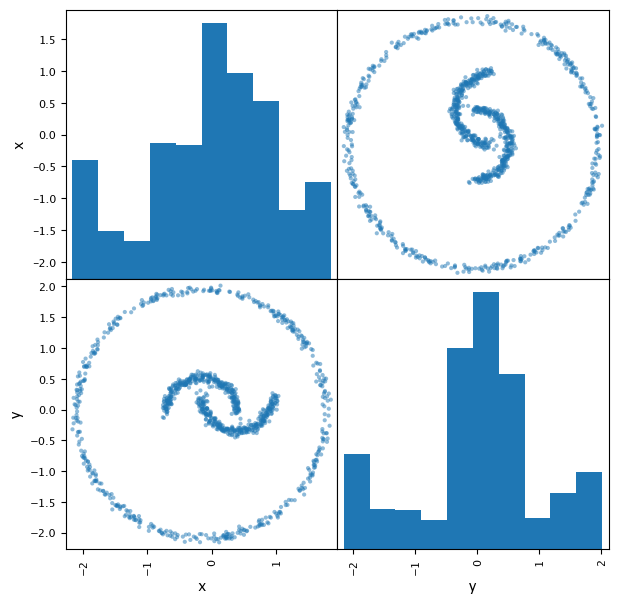

In [133]:
%matplotlib inline

scatter_matrix(standardised_dataset_1_df, figsize=(7, 7))

plt.show()

*<center>Figure 2: Scatter Matrix Visualisation</center>*

We can definitely see a natural clustering here. Let's look at the different clustering algorithms provided by `sklearn.cluster` so we can get a better idea which is best suited for our dataset.

#### 1.5.2 Select Clustering Algorithms

![](./images/clustering-algorithms.png)

*<center>Figure 3: `sklearn` Clustering Algorithms[<sup>2</sup>](#a1-references)</center>*

If we look through the different clustering algorithms referenced in **Figure 3**, we can identify the following as being contenders:
- `DBSCAN`.
- `HDBSCAN`.
- `OPTICS`.

The reason for the selection is by reflecting on the data visualisation of our dataset illustrated in **Figure 2**. We are looking for a solution that can appropriately cluster the outer circle and inner shapes as reflected by the shape of our dataset. If we evaluate the first two rows of **Figure 3**, we can see that our selected options seem suited to appropriately cluster our dataset, based on the shapes and resulting splits demonstrated.

> Note: While `Spectral Clustering` also reflects the dataset, the execution time is significantly higher and requires a different method to evaluate performance from the rest, so is excluded from this report.

### 1.6 DBSCAN

#### 1.6.1 Build the Model

In [225]:
def dbscan_model(X):
    dbscan = DBSCAN()
    dbscan.fit(X)

    labels = dbscan.labels_
    print(f'labels = {labels}')

    label_set = set(labels)
    print(f'label_set = {label_set}')

    label_list = list(labels)
    print(f'label_list[0:10] = {label_list[0:10]}')

    noise_point_count = label_list.count(-1)
    print(f'noise_point_count = {noise_point_count}')

    return dbscan

dbscan = dbscan_model(standardised_dataset_1_df)

labels = [0 0 0 ... 1 1 1]
label_set = {np.int64(0), np.int64(1)}
label_list[0:10] = [np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0)]
noise_point_count = 0


#### 1.6.2 Generate Silhouette Score

In [226]:
db_labels = np.ravel(dbscan.labels_).astype(int)

print(f'DBSCAN Score: {silhouette_score(standardised_dataset_1_df, db_labels)}')

DBSCAN Score: 0.27060252973364857


#### 1.6.3 Visualise the Data

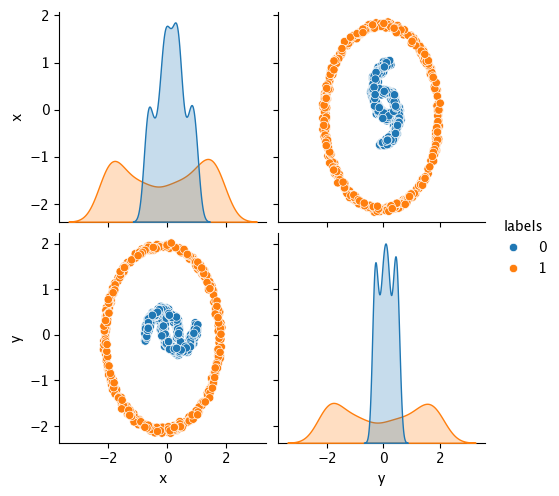

In [227]:
X = standardised_dataset_1_df.copy(['x', 'y']).copy()
X['labels'] = dbscan.labels_
sns.pairplot(X, hue='labels')

plt.show()

### 1.7 HDBSCAN

#### 1.7.1 Build the Model

In [228]:
def hdbscan_model(X):
    hdbscan = HDBSCAN()
    hdbscan.fit(X)

    labels = hdbscan.labels_
    print(f'labels = {labels}')

    label_set = set(labels)
    print(f'label_set = {label_set}')

    label_list = list(labels)
    print(f'label_list[0:10] = {label_list[0:10]}')

    noise_point_count = label_list.count(-1)
    print(f'noise_point_count = {noise_point_count}')

    return hdbscan

hdbscan = hdbscan_model(standardised_dataset_1_df)

labels = [1 2 2 ... 0 0 0]
label_set = {np.int64(0), np.int64(1), np.int64(2), np.int64(-1)}
label_list[0:10] = [np.int64(1), np.int64(2), np.int64(2), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(2), np.int64(1), np.int64(2)]
noise_point_count = 1


/Users/alexrandall/Documents/Oxford/Coursework/CML/Assignment/cml-assignment/.venv/lib/python3.11/site-packages/sklearn/cluster/_hdbscan/hdbscan.py:722: FutureWarning: The default value of `copy` will change from False to True in 1.10. Explicitly set a value for `copy` to silence this warning.
  warn(


#### 1.7.2 Generate Silhouette Score

In [229]:
hdb_labels = np.ravel(hdbscan.labels_).astype(int)

print(f'HDBSCAN Score: {silhouette_score(standardised_dataset_1_df, hdb_labels)}')

HDBSCAN Score: -0.14212058855056256


#### 1.7.3 Visualise the Data

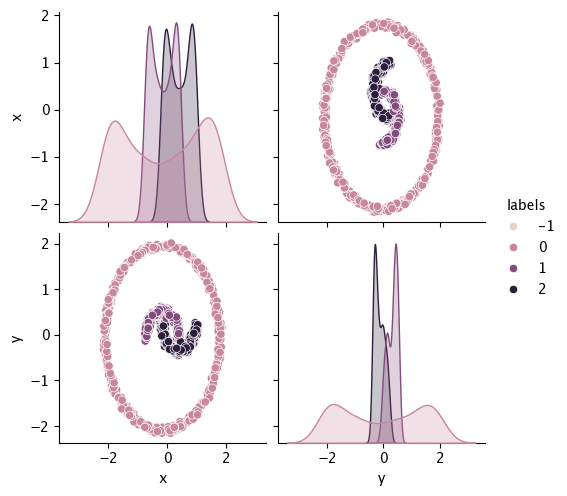

In [230]:
X = standardised_dataset_1_df.copy(['x', 'y']).copy()
X['labels'] = hdbscan.labels_
sns.pairplot(X, hue='labels')

plt.show()

### 1.8 OPTICS

#### 1.8.1 Build the Model

In [231]:
def optics_model(X):
    optics = OPTICS(min_samples=50)
    optics.fit(X)

    labels = optics.labels_
    print(f'labels = {labels}')

    label_set = set(labels)
    print(f'label_set = {label_set}')

    label_list = list(labels)
    print(f'label_list[0:10] = {label_list[0:10]}')

    noise_point_count = label_list.count(-1)
    print(f'noise_point_count = {noise_point_count}')

    return optics

optics = optics_model(standardised_dataset_1_df)

labels = [-1  1  1 ... -1 -1  3]
label_set = {np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(-1)}
label_list[0:10] = [np.int64(-1), np.int64(1), np.int64(1), np.int64(-1), np.int64(-1), np.int64(0), np.int64(-1), np.int64(1), np.int64(-1), np.int64(1)]
noise_point_count = 532


#### 1.8.2 Generate Silhouette Score

In [232]:
optics_labels = np.ravel(optics.labels_).astype(int)

print(f'OPTICS Score: {silhouette_score(standardised_dataset_1_df, optics_labels)}')

OPTICS Score: 0.07572251599813357


#### 1.8.3 Visualise the Data

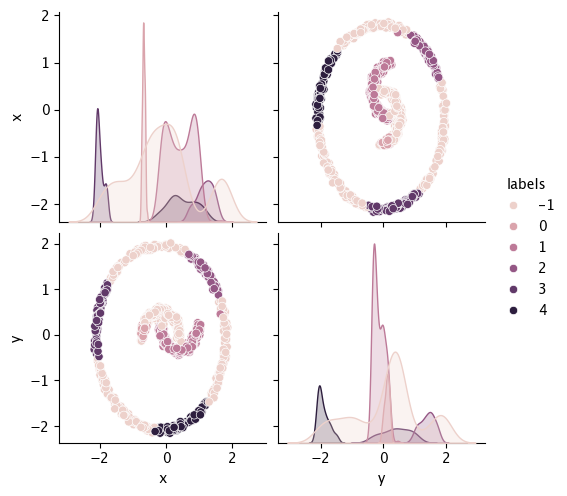

In [233]:
X = standardised_dataset_1_df.copy(['x', 'y']).copy()
X['labels'] = optics.labels_
sns.pairplot(X, hue='labels')

plt.show()

## 2. `dataset_2.csv`

## 3. `dataset_3.csv`

## 4. `dataset_4.csv`

## A. Appendix

### A.1 References

1. Accuracy of decimal places in latitude and longitude degrees: Garmin Customer Support (no date) Garmin. Available at: [https://support.garmin.com/en-US/?faq=hRMBoCTy5a7HqVkxukhHd8](https://support.garmin.com/en-US/?faq=hRMBoCTy5a7HqVkxukhHd8) (Accessed: 24 May 2026).
1. R. Collins, 'Classical Machine Learning v12' [PDF Slides], CML: Classical Machine Learning, University of Oxford, April 20 2026, [https://drive.google.com/file/d/1V0gkCj7rF6CF2l1-HteD9hN3f5FMwBwC/view?usp=drive_link](https://drive.google.com/file/d/1V0gkCj7rF6CF2l1-HteD9hN3f5FMwBwC/view?usp=drive_link) (Accessed: 24 May 2026).